# REAL ESTATE PROJECT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import re
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")

#### GET ALL THE DATA (Get The URL -> Check The Response [200]) 

In [6]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

cities = ["Hyderabad", "Mumbai", "Bangalore", "Chennai"]

all_data = []

for city in cities:
    print(f"\nScraping {city}")
    
    for page in range(1, 8):
        print(f"Page {page}")
        
        url = f"https://www.magicbricks.com/property-for-sale/residential-real-estate?cityName={city}&page={page}"
        
        response = requests.get(url, headers=headers)
        
        if response.status_code != 200:
            print("Failed:", response.status_code)
            continue
        
        soup = BeautifulSoup(response.text, "html.parser")
        cards = soup.find_all("div", class_="mb-srp__card")
        
        print("Cards found:", len(cards))
        
        for card in cards:
            try:
                title_tag = card.find("h2", class_="mb-srp__card--title")
                if not title_tag:
                    continue
                
                full_title = title_tag.get("title")
                
                # Extract BHK
                bhk_match = re.search(r'(\d+)\s*BHK', full_title)
                bhk = bhk_match.group(1) if bhk_match else None
                
                # Extract Property Type
                property_type = None
                if "BHK" in full_title:
                    property_type = "Flat"
                elif "Plot" in full_title:
                    property_type = "Plot"
                elif "Villa" in full_title:
                    property_type = "Villa"
                elif "Office" in full_title:
                    property_type = "Office"
                else:
                    property_type = "Other"
                
                # Extract Locality
                if " for Sale in " in full_title:
                    locality = full_title.split(" for Sale in ")[-1].strip()
                else:
                    locality = None
                
                # Extract Area (raw)
                area = None
                summary_items = card.find_all("div", class_="mb-srp__card__summary--value")
                for item in summary_items:
                    text = item.text.lower()
                    if "sqft" in text or "sqyrd" in text:
                        area = item.text.strip()
                        break
                
                # Extract Price (raw)
                price_tag = card.find("div", class_="mb-srp__card__price--amount")
                price = price_tag.text.strip() if price_tag else None
                
                # Extract Price per sqft (raw)
                price_sqft_tag = card.find("div", class_="mb-srp__card__price--size")
                price_per_sqft = price_sqft_tag.text.strip() if price_sqft_tag else None
                
                all_data.append([
                    city,
                    locality,
                    property_type,
                    bhk,
                    area,
                    price,
                    price_per_sqft
                ])
            
            except:
                continue
        
        time.sleep(2)



Scraping Hyderabad
Page 1
Cards found: 30
Page 2
Cards found: 30
Page 3
Cards found: 30
Page 4
Cards found: 30
Page 5
Cards found: 30
Page 6
Cards found: 30
Page 7
Cards found: 30

Scraping Mumbai
Page 1
Cards found: 30
Page 2
Cards found: 30
Page 3
Cards found: 30
Page 4
Cards found: 30
Page 5
Cards found: 30
Page 6
Cards found: 30
Page 7
Cards found: 30

Scraping Bangalore
Page 1
Cards found: 30
Page 2
Cards found: 30
Page 3
Cards found: 30
Page 4
Cards found: 30
Page 5
Cards found: 30
Page 6
Cards found: 30
Page 7
Cards found: 30

Scraping Chennai
Page 1
Cards found: 30
Page 2
Cards found: 30
Page 3
Cards found: 30
Page 4
Cards found: 30
Page 5
Cards found: 30
Page 6
Cards found: 30
Page 7
Cards found: 30


#### Save RAW Data

In [7]:
raw_df = pd.DataFrame(all_data, columns=[
    "City",
    "Locality",
    "Property_Type",
    "BHK",
    "Area_raw",
    "Price_raw",
    "Price_per_sqft_raw"
])

In [8]:
raw_df

,City,Locality,Property_Type,BHK,Area_raw,Price_raw,Price_per_sqft_raw
0,Hyderabad,"Somajiguda, NH 9 Hyderabad",Flat,4,3287 sqft,₹4.52 Cr,₹13755 per sqft
1,Hyderabad,Shadnagar Hyderabad,Plot,None,282 sqyrd,₹45.1 Lac,₹1778 per sqft
2,Hyderabad,Puppalguda Hyderabad,Flat,5,6610 sqft,₹8.26 Cr,₹12497 per sqft
3,Hyderabad,Begumpet Hyderabad,Flat,3,1920 sqft,₹1.72 Cr,₹8999 per sqft
4,Hyderabad,"Kokapet, Outer Ring Road Hyderabad",Flat,3,3078 sqft,₹4.92 Cr,₹15999 per sqft
...,...,...,...,...,...,...,...
835,Chennai,Medavakkam Chennai,Flat,2,987 sqft,₹80 Lac,₹8105 per sqft
836,Chennai,Perumbakkam Main Road Chennai,Plot,None,2800 sqft,₹2.10 Cr,₹7500 per sqft
837,Chennai,Varadharajapuram Chennai,Plot,None,2522 sqft,₹1.51 Cr,₹5987 per sqft
838,Chennai,Madipakkam Chennai,Flat,2,750 sqft,₹65.5 Lac,₹7192 per sqft


#### Convert Raw Data Into Csv File 

In [9]:
raw_df.to_csv("raw_property_data.csv", index=False)

In [2]:
df = pd.read_csv("raw_property_data.csv")

In [3]:
df

,City,Locality,Property_Type,BHK,Area_raw,Price_raw,Price_per_sqft_raw
0,Hyderabad,"Somajiguda, NH 9 Hyderabad",Flat,4.0,3287 sqft,₹4.52 Cr,₹13755 per sqft
1,Hyderabad,Shadnagar Hyderabad,Plot,NaN,282 sqyrd,₹45.1 Lac,₹1778 per sqft
2,Hyderabad,Puppalguda Hyderabad,Flat,5.0,6610 sqft,₹8.26 Cr,₹12497 per sqft
3,Hyderabad,Begumpet Hyderabad,Flat,3.0,1920 sqft,₹1.72 Cr,₹8999 per sqft
4,Hyderabad,"Kokapet, Outer Ring Road Hyderabad",Flat,3.0,3078 sqft,₹4.92 Cr,₹15999 per sqft
...,...,...,...,...,...,...,...
835,Chennai,Medavakkam Chennai,Flat,2.0,987 sqft,₹80 Lac,₹8105 per sqft
836,Chennai,Perumbakkam Main Road Chennai,Plot,NaN,2800 sqft,₹2.10 Cr,₹7500 per sqft
837,Chennai,Varadharajapuram Chennai,Plot,NaN,2522 sqft,₹1.51 Cr,₹5987 per sqft
838,Chennai,Madipakkam Chennai,Flat,2.0,750 sqft,₹65.5 Lac,₹7192 per sqft


#### Check For Head

In [4]:
df.head()

,City,Locality,Property_Type,BHK,Area_raw,Price_raw,Price_per_sqft_raw
0,Hyderabad,"Somajiguda, NH 9 Hyderabad",Flat,4.0,3287 sqft,₹4.52 Cr,₹13755 per sqft
1,Hyderabad,Shadnagar Hyderabad,Plot,NaN,282 sqyrd,₹45.1 Lac,₹1778 per sqft
2,Hyderabad,Puppalguda Hyderabad,Flat,5.0,6610 sqft,₹8.26 Cr,₹12497 per sqft
3,Hyderabad,Begumpet Hyderabad,Flat,3.0,1920 sqft,₹1.72 Cr,₹8999 per sqft
4,Hyderabad,"Kokapet, Outer Ring Road Hyderabad",Flat,3.0,3078 sqft,₹4.92 Cr,₹15999 per sqft


#### Check For Tail

In [5]:
df.tail()

,City,Locality,Property_Type,BHK,Area_raw,Price_raw,Price_per_sqft_raw
835,Chennai,Medavakkam Chennai,Flat,2.0,987 sqft,₹80 Lac,₹8105 per sqft
836,Chennai,Perumbakkam Main Road Chennai,Plot,NaN,2800 sqft,₹2.10 Cr,₹7500 per sqft
837,Chennai,Varadharajapuram Chennai,Plot,NaN,2522 sqft,₹1.51 Cr,₹5987 per sqft
838,Chennai,Madipakkam Chennai,Flat,2.0,750 sqft,₹65.5 Lac,₹7192 per sqft
839,Chennai,Alandur Chennai,Flat,2.0,800 sqft,₹1.10 Cr,₹11957 per sqft


#### Change Column Name

In [6]:
df.rename({"Area_raw":"Total_Area", "Price_raw":"Price","Price_per_sqft_raw":"Price_Per_Sqft"}, axis = 1, inplace = True)

#### Description The DataFrame

In [7]:
df.describe()

,BHK
count,726.000000
mean,3.020661
std,0.865181
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,7.000000


#### Info Of DataFrame

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            840 non-null    object 
 1   Locality        840 non-null    object 
 2   Property_Type   840 non-null    object 
 3   BHK             726 non-null    float64
 4   Total_Area      837 non-null    object 
 5   Price           840 non-null    object 
 6   Price_Per_Sqft  691 non-null    object 
dtypes: float64(1), object(6)
memory usage: 46.1+ KB


#### Check For NULL Value

In [9]:
df.isnull().sum()

City                0
Locality            0
Property_Type       0
BHK               114
Total_Area          3
Price               0
Price_Per_Sqft    149
dtype: int64

#### Ckeck & Drop Duplicates

In [10]:
df.duplicated().sum()

46

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

0

#### Clean Text Columns Using Regular Expression

##### ✔ Clean Total_Area (remove "sqft")

In [13]:
df["Total_Area"] = df["Total_Area"].str.extract(r"(\d+)").astype(float)

In [14]:
df["Total_Area"].dtype


dtype('float64')

##### ✔ Clean Price (convert Lac/Cr to numeric)

In [15]:
# Remove ₹ and strip
df["Price"] = df["Price"].str.replace("₹", "", regex=False).str.strip()

# Convert properly
def convert_price(x):
    if "Cr" in x:
        return float(x.replace("Cr", "").strip()) * 100
    elif "Lac" in x:
        return float(x.replace("Lac", "").strip())
    else:
        return None

df["Price"] = df["Price"].apply(convert_price)

In [16]:
df["Price"].dtype

dtype('float64')

##### ✔ Clean Price_per_sqft

In [17]:
df["Price_Per_Sqft"] = df["Price_Per_Sqft"].str.extract(r"(\d+)").astype(float)

In [18]:
df["Price_Per_Sqft"].dtype

dtype('float64')

#### Fix Missing Values

In [19]:
df.isnull().sum()

City                0
Locality            0
Property_Type       0
BHK               112
Total_Area          3
Price               0
Price_Per_Sqft    140
dtype: int64

##### Fix BHK for Plot Properties

In [20]:
df.loc[df["Property_Type"] == "Plot", "BHK"] = 0

In [21]:
df["BHK"].isnull().sum()

22

###### Fill remaining missing values

In [22]:
df["BHK"] = df["BHK"].fillna(df["BHK"].median())

In [23]:
df["BHK"].isnull().sum()

0

###### Convert to integer

In [24]:
df["BHK"] = df["BHK"].astype(int)

#### Fix Total_Area Missing

In [25]:
df = df.dropna(subset=["Total_Area"])

In [26]:
df["Total_Area"].isnull().sum()

0

#### Fix Price_Per_Sqft 

In [32]:
df["Price_Per_Sqft"] = df["Price"] / df["Total_Area"]

In [33]:
df["Price_Per_Sqft"].isnull().sum()

0

In [34]:
df.dtypes

City               object
Locality           object
Property_Type      object
BHK                 int32
Total_Area        float64
Price             float64
Price_Per_Sqft    float64
dtype: object

In [35]:
df.head()

,City,Locality,Property_Type,BHK,Total_Area,Price,Price_Per_Sqft
0,Hyderabad,"Somajiguda, NH 9 Hyderabad",Flat,4,3287.0,452.0,0.137511
1,Hyderabad,Shadnagar Hyderabad,Plot,0,282.0,45.1,0.159929
2,Hyderabad,Puppalguda Hyderabad,Flat,5,6610.0,826.0,0.124962
3,Hyderabad,Begumpet Hyderabad,Flat,3,1920.0,172.0,0.089583
4,Hyderabad,"Kokapet, Outer Ring Road Hyderabad",Flat,3,3078.0,492.0,0.159844


#### Again Check Null Value

In [36]:
df.isnull().sum()

City              0
Locality          0
Property_Type     0
BHK               0
Total_Area        0
Price             0
Price_Per_Sqft    0
dtype: int64

#### Check DataType Of DataFrame

In [37]:
df.dtypes

City               object
Locality           object
Property_Type      object
BHK                 int32
Total_Area        float64
Price             float64
Price_Per_Sqft    float64
dtype: object

#### Convert Price(LAKH TO RUPEES)

In [38]:
df["Price"] = df["Price"] * 100000
pd.options.display.float_format = '{:,.2f}'.format

In [56]:
df.head()

,City,Locality,Property_Type,BHK,Total_Area,Price,Price_Per_Sqft
0,Hyderabad,"Somajiguda, NH 9 Hyderabad",Flat,4,"3,287.00","137,511,408,579,251.58","13,751.14"
1,Hyderabad,Shadnagar Hyderabad,Plot,0,282.00,"159,929,078,014,184.41","15,992.91"
2,Hyderabad,Puppalguda Hyderabad,Flat,5,"6,610.00","124,962,178,517,397.88","12,496.22"
3,Hyderabad,Begumpet Hyderabad,Flat,3,"1,920.00","89,583,333,333,333.34","8,958.33"
4,Hyderabad,"Kokapet, Outer Ring Road Hyderabad",Flat,3,"3,078.00","159,844,054,580,896.69","15,984.41"


#### Change Price_Per_Sqft DataType (FLOAT TO INTEGER)

In [39]:
df["Price_Per_Sqft"] = (df["Price"] / df["Total_Area"]).round().astype("int64")

In [40]:
df.dtypes

City               object
Locality           object
Property_Type      object
BHK                 int32
Total_Area        float64
Price             float64
Price_Per_Sqft      int64
dtype: object

In [41]:
df.head()

,City,Locality,Property_Type,BHK,Total_Area,Price,Price_Per_Sqft
0,Hyderabad,"Somajiguda, NH 9 Hyderabad",Flat,4,"3,287.00","45,200,000.00",13751
1,Hyderabad,Shadnagar Hyderabad,Plot,0,282.00,"4,510,000.00",15993
2,Hyderabad,Puppalguda Hyderabad,Flat,5,"6,610.00","82,600,000.00",12496
3,Hyderabad,Begumpet Hyderabad,Flat,3,"1,920.00","17,200,000.00",8958
4,Hyderabad,"Kokapet, Outer Ring Road Hyderabad",Flat,3,"3,078.00","49,200,000.00",15984


#### Remove City Name From Locality Column(USE REGULAR EXPRESSION)

In [42]:
df["Locality"] = df.apply(
    lambda x: x["Locality"].replace(x["City"], "").strip(), 
    axis=1
)

df["Locality"] = df["Locality"].str.rstrip(", ").str.strip()

In [43]:
df.head()

,City,Locality,Property_Type,BHK,Total_Area,Price,Price_Per_Sqft
0,Hyderabad,"Somajiguda, NH 9",Flat,4,"3,287.00","45,200,000.00",13751
1,Hyderabad,Shadnagar,Plot,0,282.00,"4,510,000.00",15993
2,Hyderabad,Puppalguda,Flat,5,"6,610.00","82,600,000.00",12496
3,Hyderabad,Begumpet,Flat,3,"1,920.00","17,200,000.00",8958
4,Hyderabad,"Kokapet, Outer Ring Road",Flat,3,"3,078.00","49,200,000.00",15984


In [44]:
df.tail()

,City,Locality,Property_Type,BHK,Total_Area,Price,Price_Per_Sqft
835,Chennai,Medavakkam,Flat,2,987.00,"8,000,000.00",8105
836,Chennai,Perumbakkam Main Road,Plot,0,"2,800.00","21,000,000.00",7500
837,Chennai,Varadharajapuram,Plot,0,"2,522.00","15,100,000.00",5987
838,Chennai,Madipakkam,Flat,2,750.00,"6,550,000.00",8733
839,Chennai,Alandur,Flat,2,800.00,"11,000,000.00",13750


#### Change Column Name Again For Proper Understading

In [47]:
df.rename({"Total_Area":"Total_Area(Sqft)", "Price":"Price(₹)","Price_per_sqft":"Price_Per_Sqft(₹)"}, axis = 1, inplace = True)

In [48]:
df

,City,Locality,Property_Type,BHK,Total_Area(Sqft),Price(₹),Price_Per_Sqft
0,Hyderabad,"Somajiguda, NH 9",Flat,4,"3,287.00","45,200,000.00",13751
1,Hyderabad,Shadnagar,Plot,0,282.00,"4,510,000.00",15993
2,Hyderabad,Puppalguda,Flat,5,"6,610.00","82,600,000.00",12496
3,Hyderabad,Begumpet,Flat,3,"1,920.00","17,200,000.00",8958
4,Hyderabad,"Kokapet, Outer Ring Road",Flat,3,"3,078.00","49,200,000.00",15984
...,...,...,...,...,...,...,...
835,Chennai,Medavakkam,Flat,2,987.00,"8,000,000.00",8105
836,Chennai,Perumbakkam Main Road,Plot,0,"2,800.00","21,000,000.00",7500
837,Chennai,Varadharajapuram,Plot,0,"2,522.00","15,100,000.00",5987
838,Chennai,Madipakkam,Flat,2,750.00,"6,550,000.00",8733


In [ ]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df["City"].value_counts()

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 791 entries, 0 to 839
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   City              791 non-null    object 
 1   Locality          791 non-null    object 
 2   Property_Type     791 non-null    object 
 3   BHK               791 non-null    int32  
 4   Total_Area(Sqft)  791 non-null    float64
 5   Price(₹)          791 non-null    float64
 6   Price_Per_Sqft    791 non-null    int64  
dtypes: float64(2), int32(1), int64(1), object(3)
memory usage: 46.3+ KB


In [50]:
df.describe()

,BHK,Total_Area(Sqft),Price(₹),Price_Per_Sqft
count,791.00,791.00,791.00,791.00
mean,2.64,"1,768.34","31,940,695.32","62,074.31"
std,1.24,"1,725.32","49,333,839.58","752,318.33"
min,0.00,10.00,"700,000.00",209.00
25%,2.00,946.50,"10,350,000.00","8,280.50"
50%,3.00,"1,428.00","18,700,000.00","12,956.00"
75%,3.00,"2,099.50","36,650,000.00","25,474.00"
max,7.00,"31,500.00","639,900,000.00","16,750,000.00"


In [51]:
df.isnull().sum()

City                0
Locality            0
Property_Type       0
BHK                 0
Total_Area(Sqft)    0
Price(₹)            0
Price_Per_Sqft      0
dtype: int64

In [52]:
df.duplicated().sum()

2

## FINAL CLEANING CHECKLIST

In [56]:
# 1️⃣ Remove duplicates

In [54]:
df = df.drop_duplicates()

In [55]:
df.duplicated().sum()

0

In [57]:
# 2️⃣ Remove invalid BHK
df = df[df["BHK"] > 0]

# 3️⃣ Remove unrealistic small area
df = df[df["Total_Area(Sqft)"] >= 300]

# 4️⃣ Remove extreme Price_Per_Sqft outliers (IQR method)
Q1 = df["Price_Per_Sqft"].quantile(0.25)
Q3 = df["Price_Per_Sqft"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Price_Per_Sqft"] >= lower) & 
        (df["Price_Per_Sqft"] <= upper)]

# 5️⃣ Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaning completed ✅")


Cleaning completed ✅


#### Final Varify All

In [58]:
df.describe()

,BHK,Total_Area(Sqft),Price(₹),Price_Per_Sqft
count,654.00,654.00,654.00,654.00
mean,2.96,"1,853.43","28,179,954.13","16,644.82"
std,0.84,"1,785.03","34,327,022.53","11,457.15"
min,1.00,300.00,"2,010,000.00",209.00
25%,2.00,"1,001.50","12,000,000.00","8,492.00"
50%,3.00,"1,493.00","19,850,000.00","12,498.00"
75%,3.00,"2,122.00","35,575,000.00","19,890.50"
max,7.00,"31,500.00","607,500,000.00","53,195.00"


#### Save To CSV File 

In [59]:
df.to_csv("real_estate_cleaned.csv", index=False)

### Cleaning completed ✅

## Data Analysis and Visualization (EDA)

Problem Statement:
To analyze rental properties in different locations and understand 
how features like Price, Area, BHK, City and Property Type affect rental pricing.

#### Import Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### Load Clean Dataset

In [60]:
df = pd.read_csv("real_estate_cleaned.csv")

In [61]:
df

,City,Locality,Property_Type,BHK,Total_Area(Sqft),Price(₹),Price_Per_Sqft
0,Hyderabad,"Somajiguda, NH 9",Flat,4,"3,287.00","45,200,000.00",13751
1,Hyderabad,Puppalguda,Flat,5,"6,610.00","82,600,000.00",12496
2,Hyderabad,Begumpet,Flat,3,"1,920.00","17,200,000.00",8958
3,Hyderabad,"Kokapet, Outer Ring Road",Flat,3,"3,078.00","49,200,000.00",15984
4,Hyderabad,Suchitra Road,Flat,3,"1,527.00","7,710,000.00",5049
...,...,...,...,...,...,...,...
649,Chennai,Kilpauk,Flat,3,"1,400.00","22,700,000.00",16214
650,Chennai,Uthiramerur,Other,3,"9,600.00","2,010,000.00",209
651,Chennai,Medavakkam,Flat,2,987.00,"8,000,000.00",8105
652,Chennai,Madipakkam,Flat,2,750.00,"6,550,000.00",8733


#### Understand Data

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   City              654 non-null    object 
 1   Locality          654 non-null    object 
 2   Property_Type     654 non-null    object 
 3   BHK               654 non-null    int64  
 4   Total_Area(Sqft)  654 non-null    float64
 5   Price(₹)          654 non-null    float64
 6   Price_Per_Sqft    654 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 35.9+ KB


In [66]:
df.describe()

,BHK,Total_Area(Sqft),Price(₹),Price_Per_Sqft
count,654.00,654.00,654.00,654.00
mean,2.96,"1,853.43","28,179,954.13","16,644.82"
std,0.84,"1,785.03","34,327,022.53","11,457.15"
min,1.00,300.00,"2,010,000.00",209.00
25%,2.00,"1,001.50","12,000,000.00","8,492.00"
50%,3.00,"1,493.00","19,850,000.00","12,498.00"
75%,3.00,"2,122.00","35,575,000.00","19,890.50"
max,7.00,"31,500.00","607,500,000.00","53,195.00"


#### Identify Variable Types

In [67]:
df.dtypes

City                 object
Locality             object
Property_Type        object
BHK                   int64
Total_Area(Sqft)    float64
Price(₹)            float64
Price_Per_Sqft        int64
dtype: object

### UNI-VARIATE ANALYSIS

#### A) Continuous Variables— Price(₹)

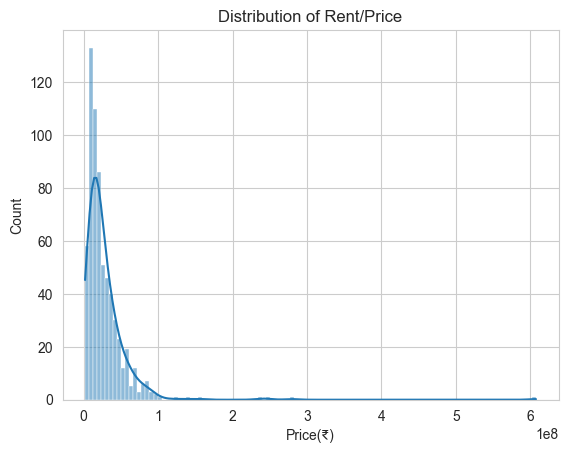

In [68]:
sns.histplot(df["Price(₹)"], kde=True)
plt.title("Distribution of Rent/Price")
plt.show()

Interpretation:
The distribution of rental price is positively skewed. Most properties are concentrated in the lower price range, while a few properties are highly priced.

Insight:
The rental market is dominated by affordable and mid-range properties. Luxury rentals exist but represent a smaller segment of the market.

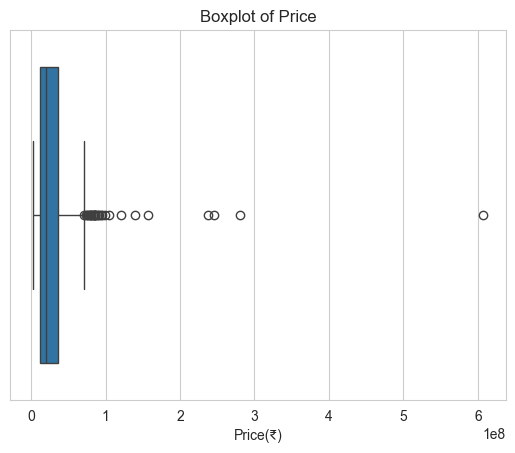

In [69]:
sns.boxplot(x=df["Price(₹)"])
plt.title("Boxplot of Price")
plt.show()

Interpretation:
The boxplot shows several outliers in the higher price range.

Insight:
These outliers indicate the presence of premium properties in prime locations.

#### B) Continuous Variable — Total_Area(Sqft)

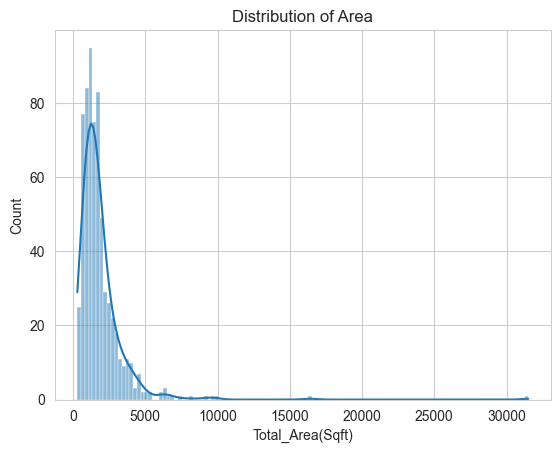

In [70]:
sns.histplot(df["Total_Area(Sqft)"], kde=True)
plt.title("Distribution of Area")
plt.show()

Interpretation:
Most properties fall within a moderate area range. Very large properties are limited.

Insight:
Rental demand appears stronger for mid-sized properties rather than extremely large homes.

#### C) Categorical Variable — City

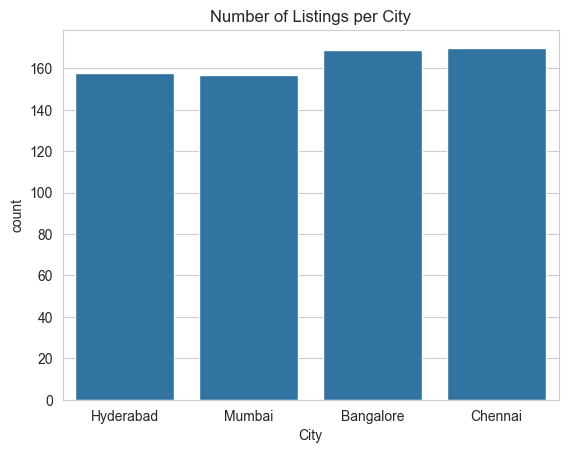

In [72]:
sns.countplot(x="City", data=df)
plt.title("Number of Listings per City")
plt.show()

Interpretation:
Listings are distributed across cities, with some cities having slightly higher counts.

Insight:
Certain cities may have higher rental activity or higher property supply.

#### D) Categorical Variable — Property_Type

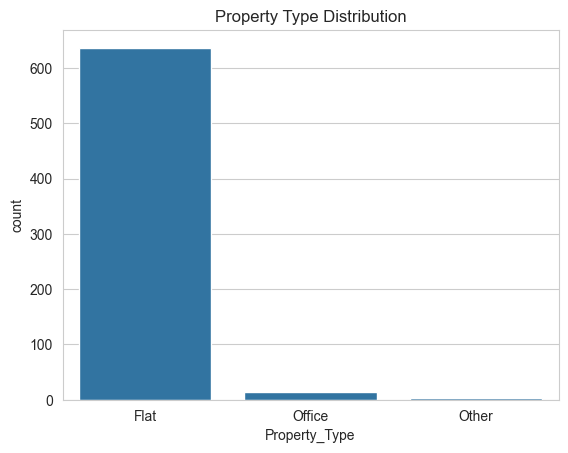

In [73]:
sns.countplot(x="Property_Type", data=df)
plt.title("Property Type Distribution")
plt.show()

Interpretation:
Flats appear more frequently than plots in the dataset.

Insight:
The rental market is primarily apartment-driven rather than land/plot-based.

### BI-VARIATE ANALYSIS

#### A) Continuous vs Continuous — Area vs Price

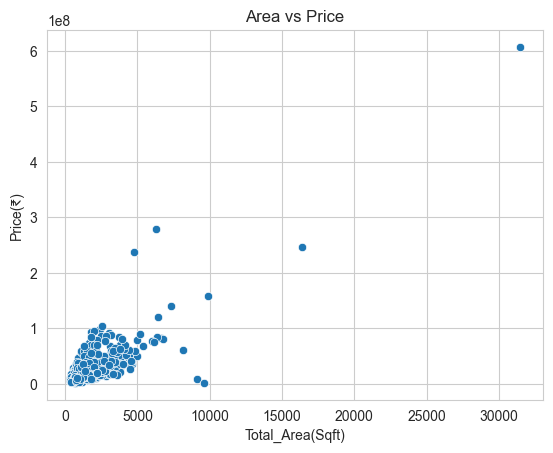

In [74]:
sns.scatterplot(x="Total_Area(Sqft)", y="Price(₹)", data=df)
plt.title("Area vs Price")
plt.show()

Interpretation:
There is a positive relationship between area and price.

Insight:
Larger properties command higher rent, making size a key pricing factor.

#### Correlation Heatmap

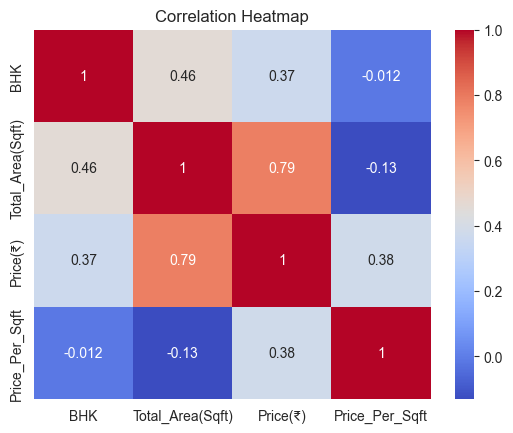

In [75]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Interpretation:
Total_Area and Price show strong positive correlation. BHK also correlates positively with Price.

Insight:
Property size and number of rooms significantly influence rental pricing.

#### Continuous vs Categorical — City vs Average Price

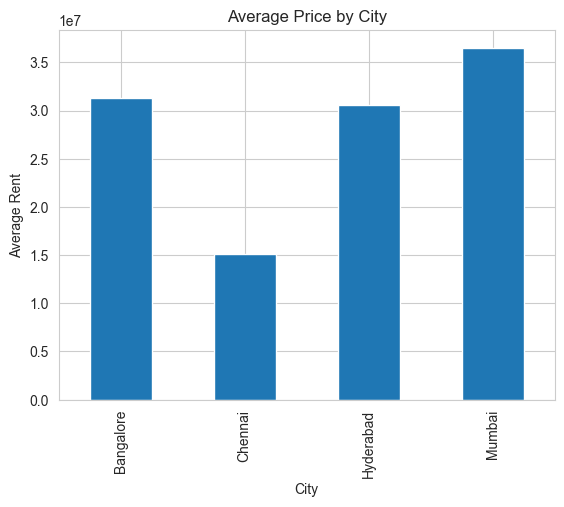

In [76]:
df.groupby("City")["Price(₹)"].mean().plot(kind="bar")
plt.title("Average Price by City")
plt.ylabel("Average Rent")
plt.show()

Interpretation:
Average rental prices vary across cities.

Insight:
Some cities represent premium rental markets compared to others.

#### BHK vs Price

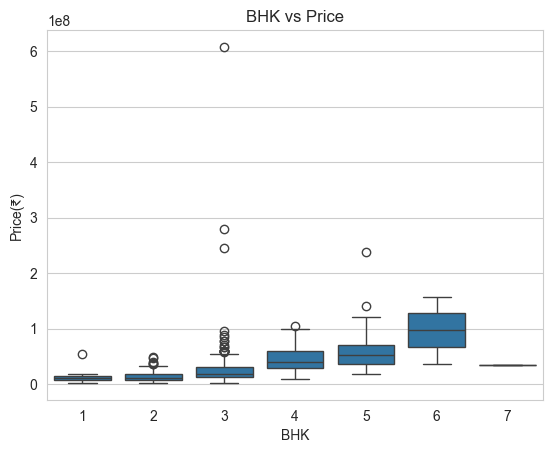

In [77]:
sns.boxplot(x="BHK", y="Price(₹)", data=df)
plt.title("BHK vs Price")
plt.show()

Interpretation:
Rent increases as the number of BHK increases.

Insight:
Tenants are willing to pay more for additional rooms, making BHK a strong pricing determinant.

#### Categorical vs Categorical — City vs Property Type

In [78]:
pd.crosstab(df["City"], df["Property_Type"])

Property_Type,Flat,Office,Other
City,,,
Bangalore,167,2,0
Chennai,166,1,3
Hyderabad,155,3,0
Mumbai,149,8,0


Interpretation:
Flats are the most common property type in all cities, while office and other types are very few.

Insight:
The rental market is mainly residential and dominated by flats across all cities.

### MULTI-VARIATE ANALYSIS

In [79]:
pd.pivot_table(df,
               values="Price_Per_Sqft",
               index="City",
               columns="Property_Type",
               aggfunc="mean")

Property_Type,Flat,Office,Other
City,,,
Bangalore,"13,701.40","29,722.00",NaN
Chennai,"10,761.27","12,833.00","6,551.00"
Hyderabad,"9,642.59","15,244.00",NaN
Mumbai,"33,015.15","32,461.12",NaN


Interpretation:
Mumbai has the highest price per sqft, while Hyderabad has comparatively lower values. Office spaces are also highly priced in some cities.

Insight:
Price per sqft depends on both city and property type, with premium cities commanding higher rental values.

### FINAL CONCLUSION

• Rental prices are strongly influenced by area, BHK, and city.
• Larger properties have higher overall rent.
• Premium cities show higher price per sqft.
• Flats dominate the rental market.
• The price distribution is positively skewed due to presence of luxury properties.

##### This analysis provides insights that can help real estate investors, property owners, and tenants understand rental pricing trends across cities.